#  Predictive Analytics Dashboard - Training Notebook

## Model Training for:
1. **Enrollment Trend Prediction** - Prophet models for each grade level
2. **Payment Growth Prediction** - Prophet model for revenue forecasting

---
### Features:
- Predicts future enrollment trends based on historical enrollment data
- Identifies the most and least enrolled grade levels per school year
- Predicts payment growth trends
- Display interactive graphs
- Generates downloadable predictive reports
---

## 1. Import All Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Prophet for Time Series
from prophet import Prophet

# Sklearn
from sklearn.metrics import mean_absolute_error, mean_squared_error

# For saving
import pickle
import os
import json

# Resolve paths relative to the notebook's working directory
BASE_DIR = os.getcwd()
MODELS_PATH = os.path.join(BASE_DIR, 'saved_models')
PLOTS_PATH = os.path.join(BASE_DIR, 'plots')
DATA_PATH = os.path.join(BASE_DIR, 'enrollment_data.txt')

# Create directories
os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(PLOTS_PATH, exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, 'forecasts'), exist_ok=True)

print("="*70)
print("PREDICTIVE ANALYTICS DASHBOARD - MODEL TRAINING")
print("="*70)
print("Model: Prophet for Enrollment & Payment Forecasting")
print(f"Base directory : {BASE_DIR}")
print(f"Models path    : {MODELS_PATH}")
print(f"Data path      : {DATA_PATH}")
print("="*70)


PREDICTIVE ANALYTICS DASHBOARD - MODEL TRAINING
Model: Prophet for Enrollment & Payment Forecasting


---
# ENROLLMENT & PAYMENT PREDICTION (Prophet)
---

## 2. Load Enrollment Data

In [ ]:
# Load enrollment data with payment
print("Loading enrollment data...")
enrollment_df = pd.read_csv(DATA_PATH)
print(f"Loaded: {len(enrollment_df)} years of data ({enrollment_df['Year'].min()}-{enrollment_df['Year'].max()})")
print(f"\nColumns: {enrollment_df.columns.tolist()}")
enrollment_df.tail(10)


Loading enrollment data...
Loaded: 8 years of data (2018-2025)

Columns: ['Year', 'Nursery 1', 'Nursery 2', 'Kinder', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4', 'Grade 5', 'Grade 6', 'TotalOverall', 'Total_Payment']


,Year,Nursery 1,Nursery 2,Kinder,Grade 1,Grade 2,Grade 3,Grade 4,Grade 5,Grade 6,TotalOverall,Total_Payment
0,2018,8,14,18,15,14,13,11,10,0,104,177900
1,2019,9,15,19,15,14,13,11,10,0,107,183600
2,2020,8,14,18,14,14,13,11,10,0,104,177900
3,2021,9,15,19,15,13,13,11,10,0,106,181800
4,2022,8,14,18,15,14,13,11,10,0,105,179850
5,2023,9,16,20,17,14,13,11,17,0,117,195000
6,2024,9,17,23,21,19,13,15,9,16,142,236700
7,2025,9,17,26,25,21,20,11,12,9,150,255900


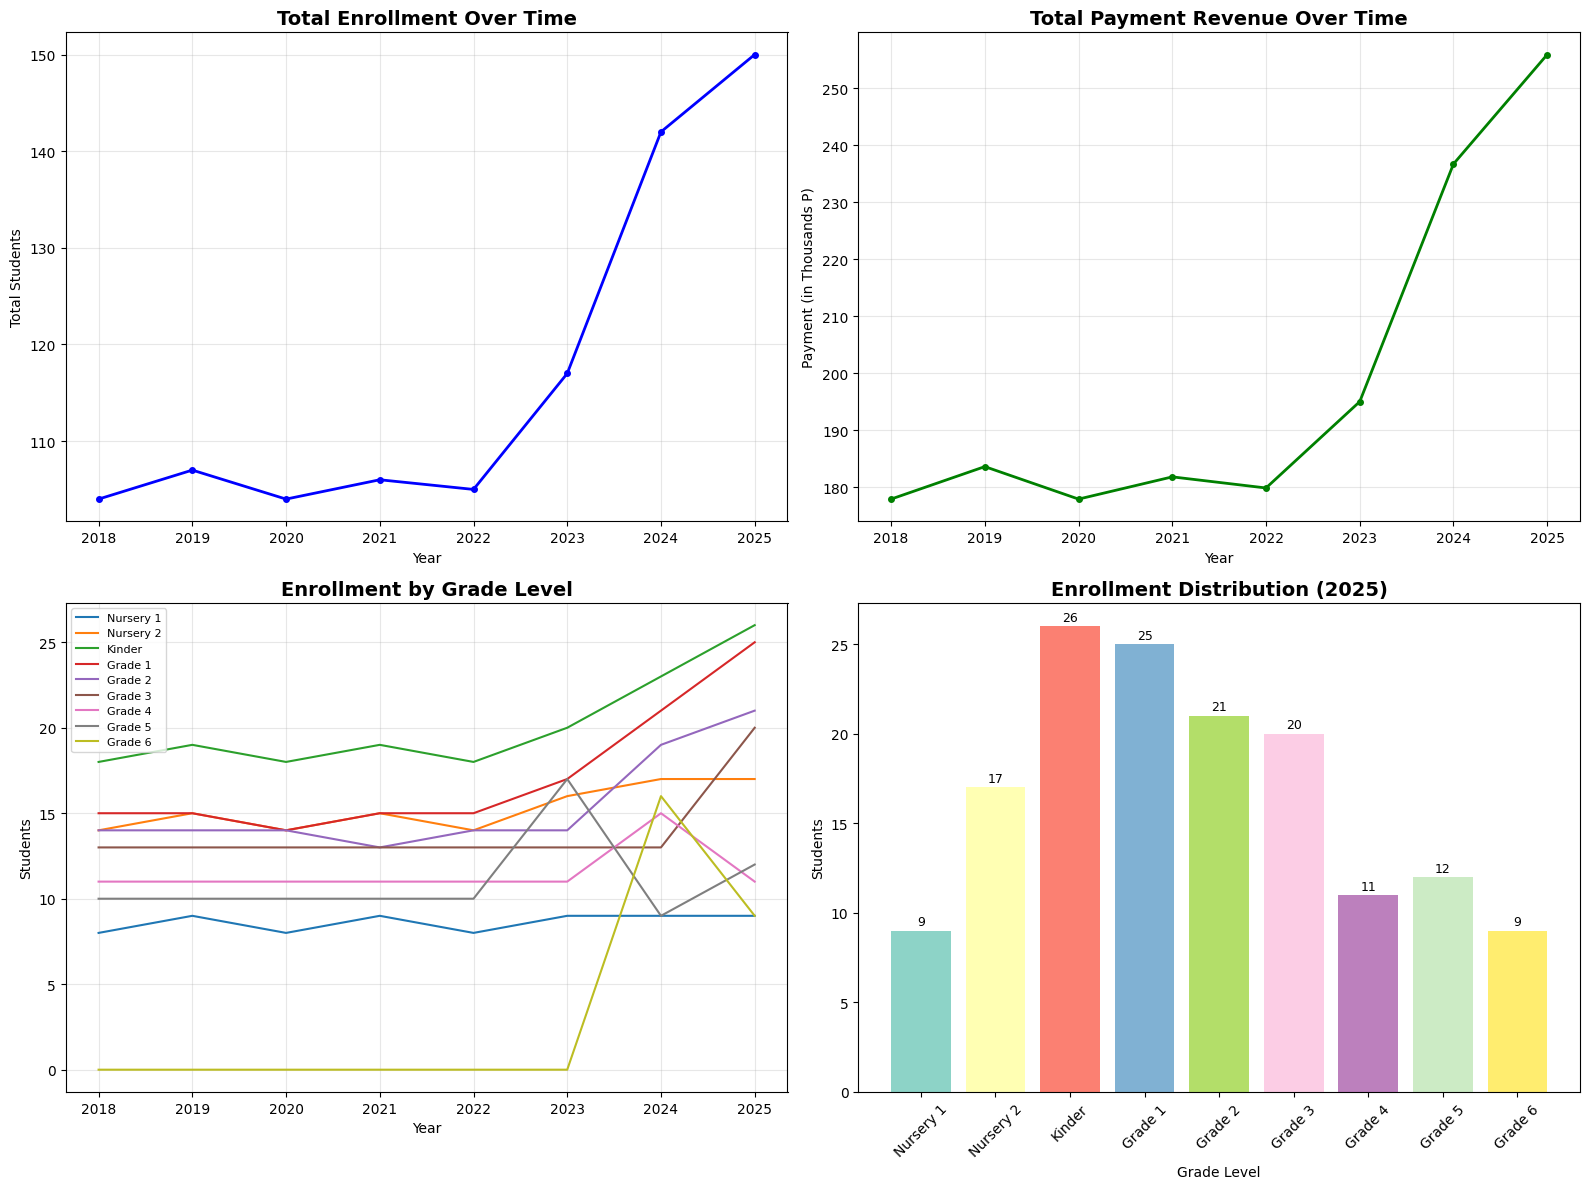

Saved: plots/historical_overview.png


In [ ]:
# Visualize historical data
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Total Enrollment Trend
axes[0, 0].plot(enrollment_df['Year'], enrollment_df['TotalOverall'], 'b-o', linewidth=2, markersize=4)
axes[0, 0].set_title('Total Enrollment Over Time', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Total Students')
axes[0, 0].grid(True, alpha=0.3)

# Payment Trend
axes[0, 1].plot(enrollment_df['Year'], enrollment_df['Total_Payment']/1000, 'g-o', linewidth=2, markersize=4)
axes[0, 1].set_title('Total Payment Revenue Over Time', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Payment (in Thousands P)')
axes[0, 1].grid(True, alpha=0.3)

# Grade Level Comparison
grade_cols = ['Nursery 1', 'Nursery 2', 'Kinder', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4', 'Grade 5', 'Grade 6']
for col in grade_cols:
    axes[1, 0].plot(enrollment_df['Year'], enrollment_df[col], label=col, linewidth=1.5)
axes[1, 0].set_title('Enrollment by Grade Level', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Students')
axes[1, 0].legend(loc='upper left', fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# Latest Year Distribution
latest = enrollment_df.iloc[-1]
colors = plt.cm.Set3(np.linspace(0, 1, len(grade_cols)))
bars = axes[1, 1].bar(grade_cols, [latest[col] for col in grade_cols], color=colors)
axes[1, 1].set_title(f'Enrollment Distribution ({int(latest["Year"])})', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Grade Level')
axes[1, 1].set_ylabel('Students')
axes[1, 1].tick_params(axis='x', rotation=45)
for bar in bars:
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    str(int(bar.get_height())), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_PATH, 'historical_overview.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {os.path.join(PLOTS_PATH, 'historical_overview.png')}")


## 3. Train Prophet Models for Enrollment Prediction

In [12]:
# Train Prophet models for each grade level
print("Training Prophet models for enrollment prediction...")
print("="*70)

grade_columns = ['Nursery 1', 'Nursery 2', 'Kinder', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4', 'Grade 5', 'Grade 6', 'TotalOverall']
enrollment_models = {}
enrollment_metrics = {}

for grade in grade_columns:
    # Prepare data for Prophet
    df_prophet = enrollment_df[['Year', grade]].copy()
    df_prophet.columns = ['ds', 'y']
    df_prophet['ds'] = pd.to_datetime(df_prophet['ds'], format='%Y')
    
    # Train model
    model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.1
    )
    model.fit(df_prophet)
    
    # Make predictions on training data
    predictions = model.predict(df_prophet)
    
    # Calculate metrics
    mae = mean_absolute_error(df_prophet['y'], predictions['yhat'])
    rmse = np.sqrt(mean_squared_error(df_prophet['y'], predictions['yhat']))
    
    enrollment_models[grade] = model
    enrollment_metrics[grade] = {'MAE': mae, 'RMSE': rmse}
    
    print(f"[OK] {grade}: MAE={mae:.2f}, RMSE={rmse:.2f}")

print("\n" + "="*70)
print("All enrollment models trained successfully!")

15:21:10 - cmdstanpy - INFO - Chain [1] start processing
15:21:11 - cmdstanpy - INFO - Chain [1] done processing


Training Prophet models for enrollment prediction...


15:21:11 - cmdstanpy - INFO - Chain [1] start processing
15:21:11 - cmdstanpy - INFO - Chain [1] done processing


[OK] Nursery 1: MAE=0.35, RMSE=0.42
[OK] Nursery 2: MAE=0.53, RMSE=0.69


15:21:11 - cmdstanpy - INFO - Chain [1] start processing
15:21:11 - cmdstanpy - INFO - Chain [1] done processing
15:21:11 - cmdstanpy - INFO - Chain [1] start processing
15:21:11 - cmdstanpy - INFO - Chain [1] done processing


...

[OK] Grade 3: MAE=1.46, RMSE=1.89
[OK] Grade 4: MAE=0.83, RMSE=1.21


15:21:12 - cmdstanpy - INFO - Chain [1] start processing
15:21:12 - cmdstanpy - INFO - Chain [1] done processing
15:21:12 - cmdstanpy - INFO - Chain [1] start processing
15:21:12 - cmdstanpy - INFO - Chain [1] done processing


[OK] Grade 5: MAE=1.43, RMSE=2.25
[OK] Grade 6: MAE=3.13, RMSE=4.14


15:21:12 - cmdstanpy - INFO - Chain [1] start processing
15:21:12 - cmdstanpy - INFO - Chain [1] done processing


[OK] TotalOverall: MAE=8.86, RMSE=9.43

All enrollment models trained successfully!


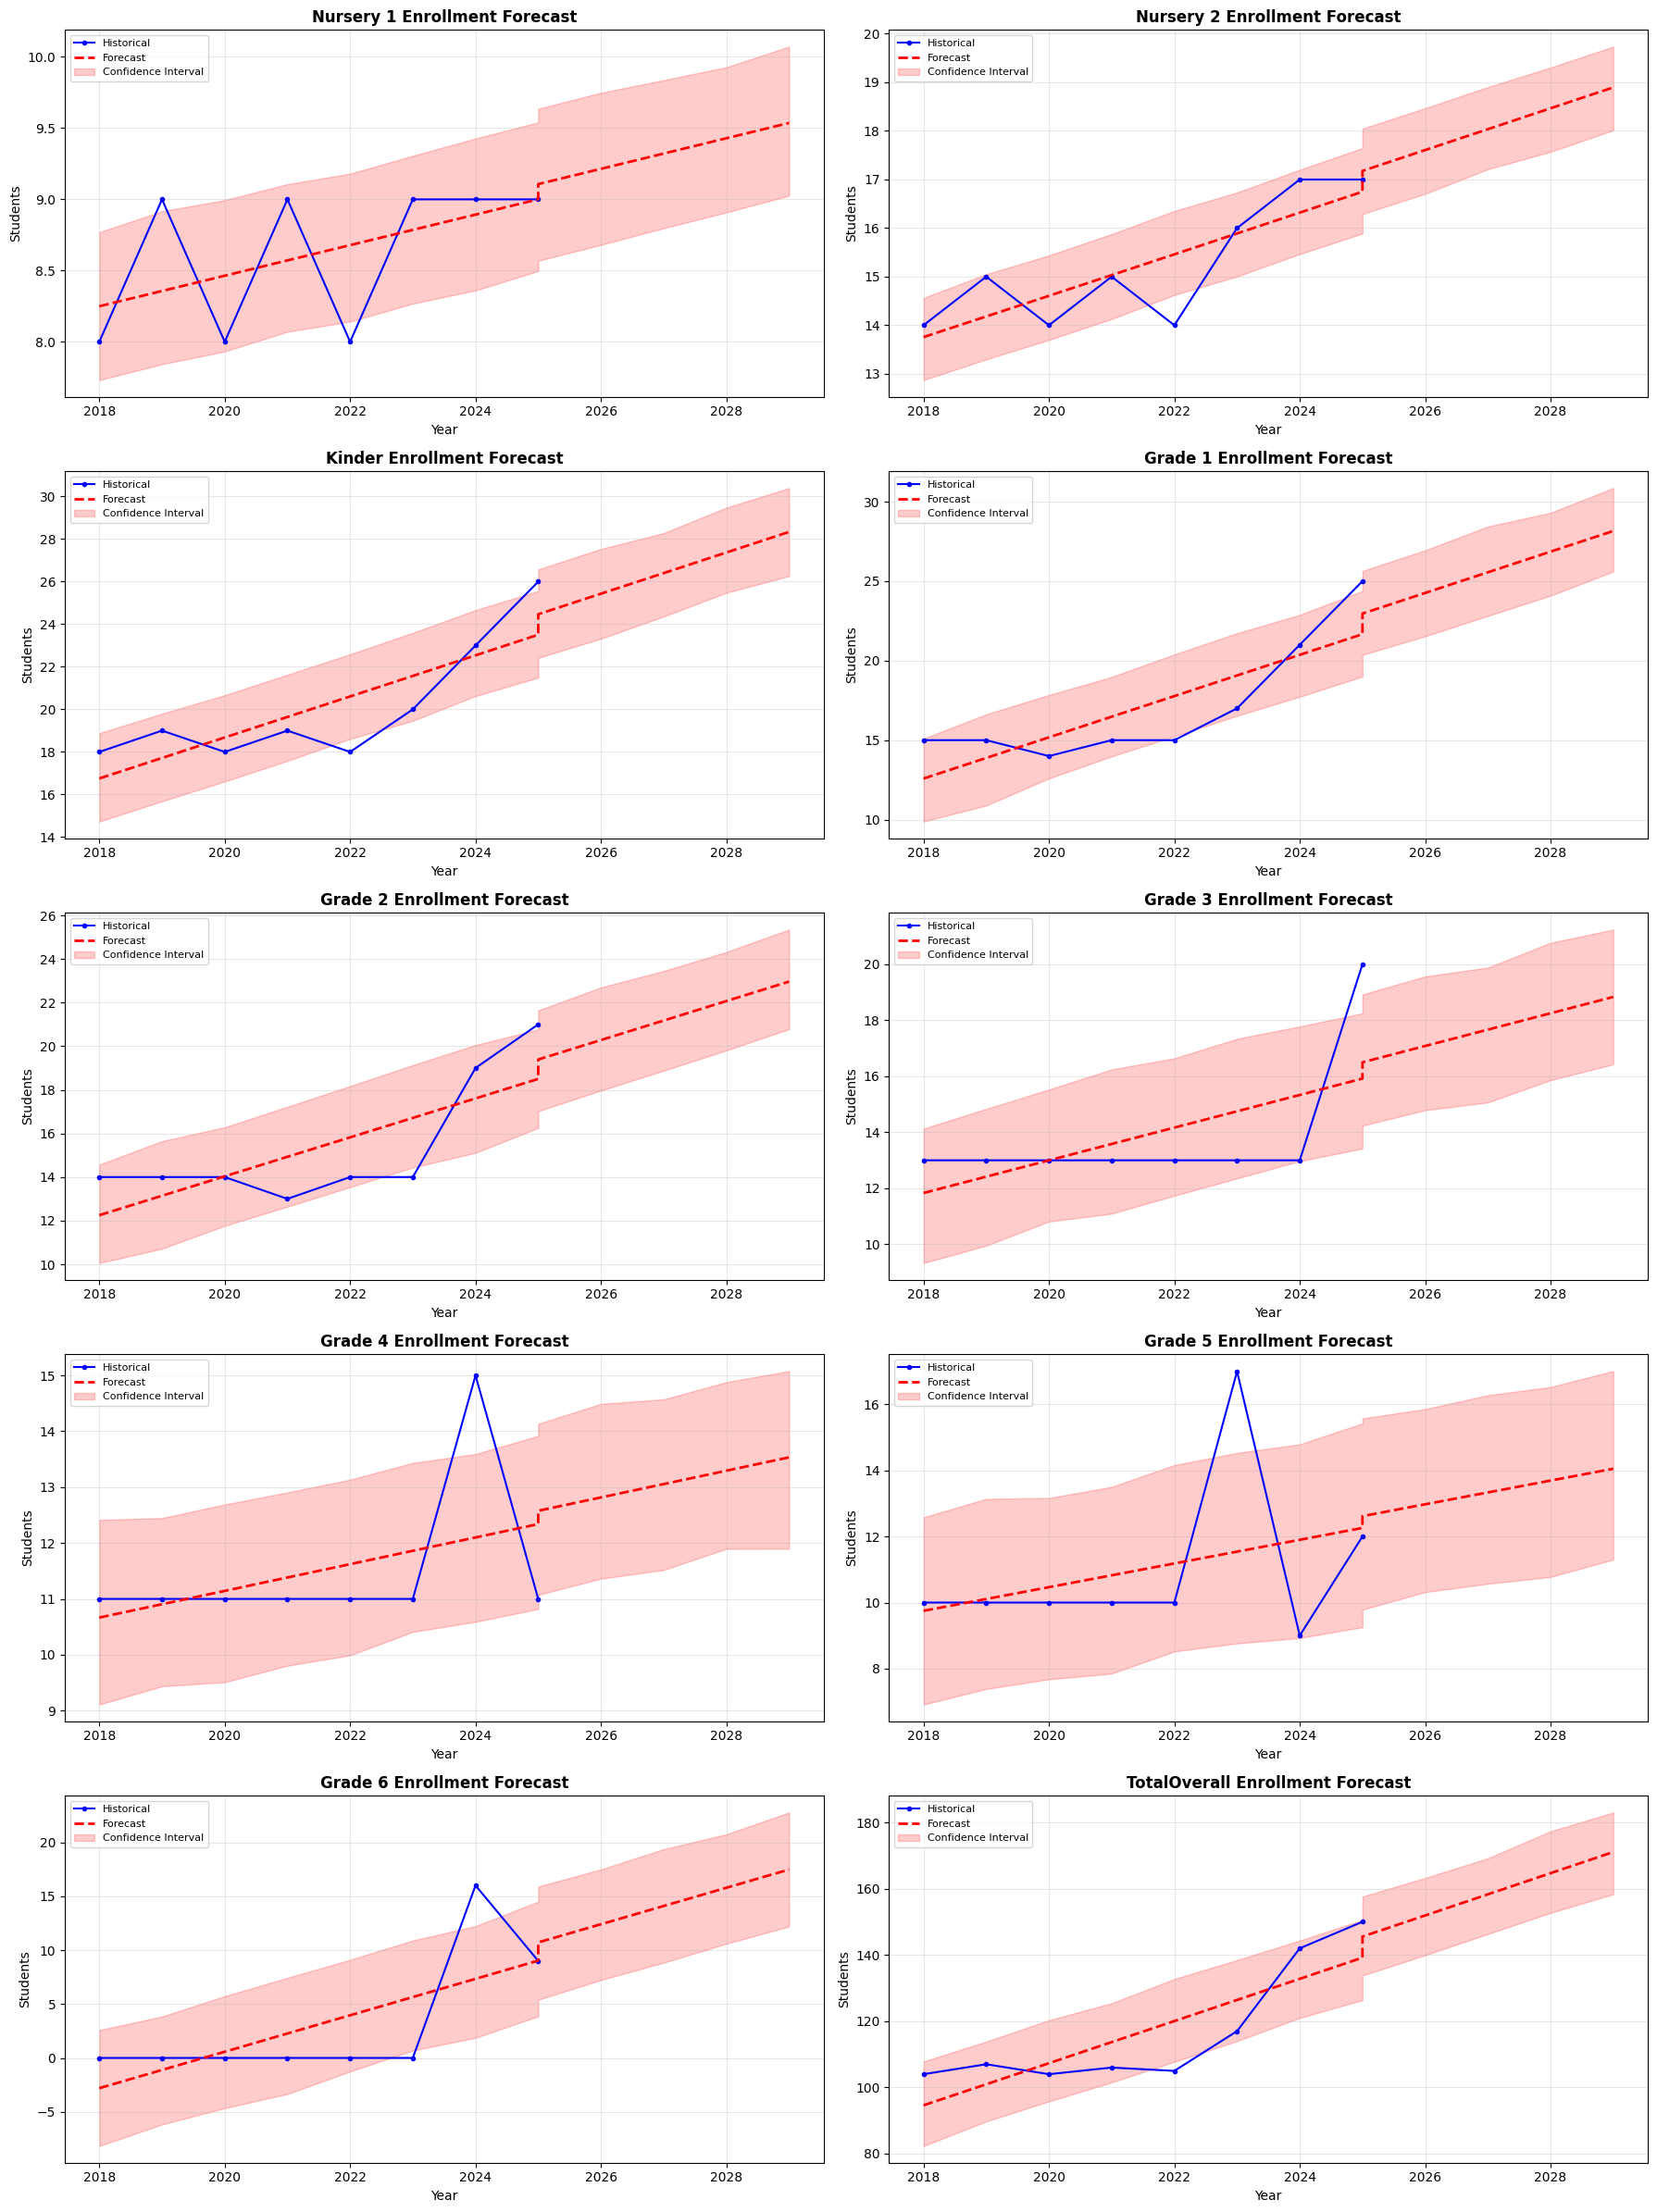

Saved: plots/enrollment_forecasts_all.png


In [ ]:
# Plot enrollment forecasts for each grade
fig, axes = plt.subplots(5, 2, figsize=(18, 24))
axes = axes.flatten()

forecast_years = 5

for idx, grade in enumerate(grade_columns):
    model = enrollment_models[grade]

    # Create future dataframe
    future = model.make_future_dataframe(periods=forecast_years, freq='YE')
    forecast = model.predict(future)

    # Plot
    ax = axes[idx]
    ax.plot(enrollment_df['Year'], enrollment_df[grade], 'bo-', label='Historical', markersize=3)
    ax.plot(forecast['ds'].dt.year, forecast['yhat'], 'r--', label='Forecast', linewidth=2)
    ax.fill_between(forecast['ds'].dt.year, forecast['yhat_lower'], forecast['yhat_upper'],
                    color='red', alpha=0.2, label='Confidence Interval')

    ax.set_title(f'{grade} Enrollment Forecast', fontsize=12, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Students')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_PATH, 'enrollment_forecasts_all.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {os.path.join(PLOTS_PATH, 'enrollment_forecasts_all.png')}")


## 4. Train Prophet Model for Payment Prediction

In [14]:
# Train Payment Prediction Model
print("Training Payment Growth Prediction Model...")
print("="*70)

# Prepare data
df_payment = enrollment_df[['Year', 'Total_Payment']].copy()
df_payment.columns = ['ds', 'y']
df_payment['ds'] = pd.to_datetime(df_payment['ds'], format='%Y')

# Train model
payment_model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.1
)
payment_model.fit(df_payment)

# Predictions
payment_predictions = payment_model.predict(df_payment)

# Metrics
payment_mae = mean_absolute_error(df_payment['y'], payment_predictions['yhat'])
payment_rmse = np.sqrt(mean_squared_error(df_payment['y'], payment_predictions['yhat']))

print(f"[OK] Payment Model: MAE=P{payment_mae:,.2f}, RMSE=P{payment_rmse:,.2f}")
print("="*70)

15:21:16 - cmdstanpy - INFO - Chain [1] start processing
15:21:16 - cmdstanpy - INFO - Chain [1] done processing


Training Payment Growth Prediction Model...
[OK] Payment Model: MAE=P14,932.73, RMSE=P16,005.78


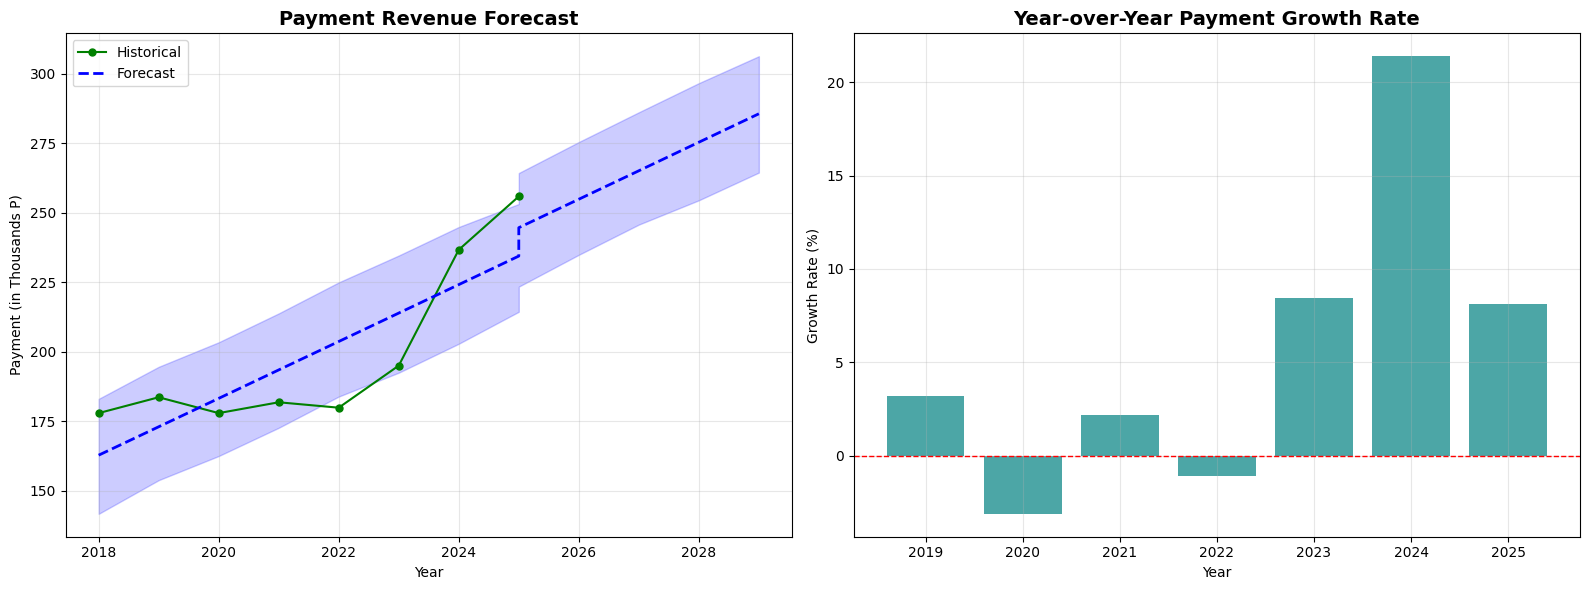

Saved: plots/payment_forecast.png


In [ ]:
# Plot Payment Forecast
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Forecast
future_payment = payment_model.make_future_dataframe(periods=5, freq='YE')
forecast_payment = payment_model.predict(future_payment)

axes[0].plot(enrollment_df['Year'], enrollment_df['Total_Payment']/1000, 'go-', label='Historical', markersize=5)
axes[0].plot(forecast_payment['ds'].dt.year, forecast_payment['yhat']/1000, 'b--', label='Forecast', linewidth=2)
axes[0].fill_between(forecast_payment['ds'].dt.year, forecast_payment['yhat_lower']/1000,
                     forecast_payment['yhat_upper']/1000, color='blue', alpha=0.2)
axes[0].set_title('Payment Revenue Forecast', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Payment (in Thousands P)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Year-over-Year Growth
enrollment_df['Payment_Growth'] = enrollment_df['Total_Payment'].pct_change() * 100
axes[1].bar(enrollment_df['Year'][1:], enrollment_df['Payment_Growth'][1:], color='teal', alpha=0.7)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Year-over-Year Payment Growth Rate', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Growth Rate (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_PATH, 'payment_forecast.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {os.path.join(PLOTS_PATH, 'payment_forecast.png')}")


## 5. Save Prophet Models

In [ ]:
# Save all Prophet models
print("Saving Prophet models...")
print("="*70)

# Save enrollment models
for grade, model in enrollment_models.items():
    safe_name = grade.replace(' ', '_').lower()
    filepath = os.path.join(MODELS_PATH, f'prophet_enrollment_{safe_name}.pkl')
    with open(filepath, 'wb') as f:
        pickle.dump(model, f)
    print(f"[OK] Saved: prophet_enrollment_{safe_name}.pkl")

# Save payment model
payment_filepath = os.path.join(MODELS_PATH, 'prophet_payment.pkl')
with open(payment_filepath, 'wb') as f:
    pickle.dump(payment_model, f)
print(f"[OK] Saved: prophet_payment.pkl")

# Save metrics
all_metrics = {
    'enrollment': enrollment_metrics,
    'payment': {'MAE': payment_mae, 'RMSE': payment_rmse}
}
metrics_filepath = os.path.join(MODELS_PATH, 'prophet_metrics.json')
with open(metrics_filepath, 'w') as f:
    json.dump(all_metrics, f, indent=2)
print(f"[OK] Saved: prophet_metrics.json")

print("\n" + "="*70)
print(f"All Prophet models saved to: {MODELS_PATH}")
print("="*70)


Saving Prophet models...
[OK] Saved: prophet_enrollment_nursery_1.pkl
[OK] Saved: prophet_enrollment_nursery_2.pkl
[OK] Saved: prophet_enrollment_kinder.pkl
[OK] Saved: prophet_enrollment_grade_1.pkl
[OK] Saved: prophet_enrollment_grade_2.pkl
[OK] Saved: prophet_enrollment_grade_3.pkl
[OK] Saved: prophet_enrollment_grade_4.pkl
[OK] Saved: prophet_enrollment_grade_5.pkl
[OK] Saved: prophet_enrollment_grade_6.pkl
[OK] Saved: prophet_enrollment_totaloverall.pkl
[OK] Saved: prophet_payment.pkl
[OK] Saved: prophet_metrics.json

All Prophet models saved!
